## Bibliotecas

In [97]:
import pandas as pd
import plotly.express as px
import ast
import matplotlib.pyplot as plt
import ast
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict)
from sklearn.metrics import (
    classification_report,
    confusion_matrix)
import seaborn as sns
from sklearn.metrics import f1_score
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# Quantidade de frases por autor

In [98]:
df = pd.read_csv("Frases_completo.csv")
df["autor"].value_counts()

autor
Albert Einstein           10
J.K. Rowling               9
Marilyn Monroe             7
Dr. Seuss                  6
Mark Twain                 6
Jane Austen                5
C.S. Lewis                 5
Bob Marley                 3
Eleanor Roosevelt          2
Ralph Waldo Emerson        2
Mother Teresa              2
George R.R. Martin         2
Ernest Hemingway           2
Charles Bukowski           2
Suzanne Collins            2
André Gide                 1
Thomas A. Edison           1
Steve Martin               1
Douglas Adams              1
Elie Wiesel                1
Friedrich Nietzsche        1
Allen Saunders             1
Pablo Neruda               1
Garrison Keillor           1
Jim Henson                 1
Charles M. Schulz          1
William Nicholson          1
Jorge Luis Borges          1
George Eliot               1
Martin Luther King Jr.     1
James Baldwin              1
Haruki Murakami            1
Alexandre Dumas fils       1
Stephenie Meyer            1
Helen Ke

# Tags mais citadas

In [ ]:
import ast
import pandas as pd

# converter strings para listas
df["tags"] = df["tags"].apply(
    lambda x: ast.literal_eval(x)
    if isinstance(x, str)
    else []
)

# explode
tags_explodidas = df.explode("tags")

# remover vazios/nulos
tags_explodidas = tags_explodidas[
    tags_explodidas["tags"].notna()
]

# remover espaços extras
tags_explodidas["tags"] = (
    tags_explodidas["tags"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# contar
contagem_tags = (
    tags_explodidas["tags"]
    .value_counts()
)

print(contagem_tags.head(10))

In [ ]:
df["tags"].apply(type).value_counts()
tags_explodidas = df.explode("tags").reset_index(drop=True)

In [ ]:
tabela_autor_tag = pd.crosstab(
    tags_explodidas["autor"],
    tags_explodidas["tags"]
)
contagem_autores = df["autor"].value_counts()

autores_relevantes = contagem_autores[
    contagem_autores >= 3
].index.tolist()


tabela_filtrada = tabela_autor_tag[
    tabela_autor_tag.index.isin(autores_relevantes)
]

# Palavras mais frequentes

In [ ]:
texto = " ".join(df["frase_sem_stopwords"])
palavras = texto.split()

frequencia = Counter(palavras)

print(frequencia.most_common(20))
top20 = frequencia.most_common(20)

palavras = [p[0] for p in top20]
freqs = [p[1] for p in top20]

# Palavras mais frequentes por autor

In [ ]:
autores_relevantes = df["autor"].value_counts()

autores_relevantes = autores_relevantes[
    autores_relevantes >= 3
].index

for autor in autores_relevantes:

    print("\n")
    print("="*50)
    print(f"Autor: {autor}")

    frases_autor = df[
        df["autor"] == autor
    ]["frase_sem_stopwords"]

    texto_autor = " ".join(frases_autor)

    palavras_autor = texto_autor.split()

    frequencia_autor = Counter(palavras_autor)

    print(frequencia_autor.most_common(3))

# Tamanho das frases por autor
Autores com pelo menos 3 frases

In [ ]:
df["tamanho_frase"] = df["frase"].apply(
    lambda x: len(x.split())
)

contagem_autores = df["autor"].value_counts()

autores_relevantes = contagem_autores[
    contagem_autores >= 3
].index

media_tamanho = (
    df[df["autor"].isin(autores_relevantes)]
    .groupby("autor")["tamanho_frase"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

media_tamanho.plot(kind="bar")

plt.title("Média do tamanho das frases por autor")
plt.xlabel("Autor")
plt.ylabel("Número médio de palavras")

plt.xticks(rotation=45)

plt.show()

estatisticas_autores = (
    df[df["autor"].isin(autores_relevantes)]
    .groupby("autor")
    .agg(
        media_tamanho=("tamanho_frase", "mean"),
        quantidade_frases=("frase", "count")
    )
    .sort_values(by="media_tamanho", ascending=False)
)

print(estatisticas_autores)

# Palavras mais importantes por autor

In [ ]:
contagem_autores = df_tfidf["autor"].value_counts()

autores_relevantes = contagem_autores[
    contagem_autores >= 3
].index

tfidf_filtrado = df_tfidf[
    df_tfidf["autor"].isin(autores_relevantes)
]

colunas_texto = ["autor", "frase", "tags"]

colunas_tfidf = [
    col for col in tfidf_filtrado.columns
    if col not in colunas_texto
]

media_tfidf_autor = (
    tfidf_filtrado
    .groupby("autor")[colunas_tfidf]
    .mean()
)

for autor in media_tfidf_autor.index:

    print("\n")
    print("="*50)
    print(f"Autor: {autor}")

    top_palavras = (
        media_tfidf_autor.loc[autor]
        .sort_values(ascending=False)
        .head(10)
    )

    print(top_palavras)

# K-Means
Existem grupos naturais de frases semelhantes? 

O TfidfVectorizer() do sklearn já faz:
- TF
- IDF suavizado
- normalização
- tokenização
- remoção de inconsistências

O nosso TF_IDF não está dando certo

In [115]:
vectorizer = TfidfVectorizer(
)
X = vectorizer.fit_transform(
    df["frase_sem_stopwords"]
)

In [122]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

kmeans.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [123]:
df["cluster"] = kmeans.labels_

import pandas as pd

termos = vectorizer.get_feature_names_out()

for i in range(3):

    print("\n")
    print("="*50)
    print(f"CLUSTER {i}")

    centroide = kmeans.cluster_centers_[i]

    indices = centroide.argsort()[-10:][::-1]

    palavras = [termos[indice] for indice in indices]

    print(palavras)



CLUSTER 0
['love', 'one', 'life', 'like', 'know', 'never', 'person', 'book', 'read', 'good']


CLUSTER 1
['truth', 'get', 'better', 'hurt', 'lie', 'hated', 'absolutely', 'enough', 'loved', 'never']


CLUSTER 2
['think', 'may', 'go', 'love', 'else', 'music', 'give', 'make', 'everyone', 'sitting']


In [124]:
for cluster in sorted(df["cluster"].unique()):

    print("\n")
    print("="*60)
    print(f"CLUSTER {cluster}")

    frases_cluster = df[
        df["cluster"] == cluster
    ]["frase"]

    for frase in frases_cluster:

        print("-", frase)



CLUSTER 0
- “The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”
- “It is our choices, Harry, that show what we truly are, far more than our abilities.”
- “There are only two ways to live your life. One is as though nothing is a miracle. The other is as though everything is a miracle.”
- “The person, be it gentleman or lady, who has not pleasure in a good novel, must be intolerably stupid.”
- “Try not to become a man of success. Rather become a man of value.”
- “I have not failed. I've just found 10,000 ways that won't work.”
- “A woman is like a tea bag; you never know how strong it is until it's in hot water.”
- “A day without sunshine is like, you know, night.”
- “It takes a great deal of bravery to stand up to our enemies, but just as much to stand up to our friends.”
- “If you can't explain it to a six year old, you don't understand it yourself.”
- “I like nonsense, it wakes up the brain cells. Fantasy is a necessary

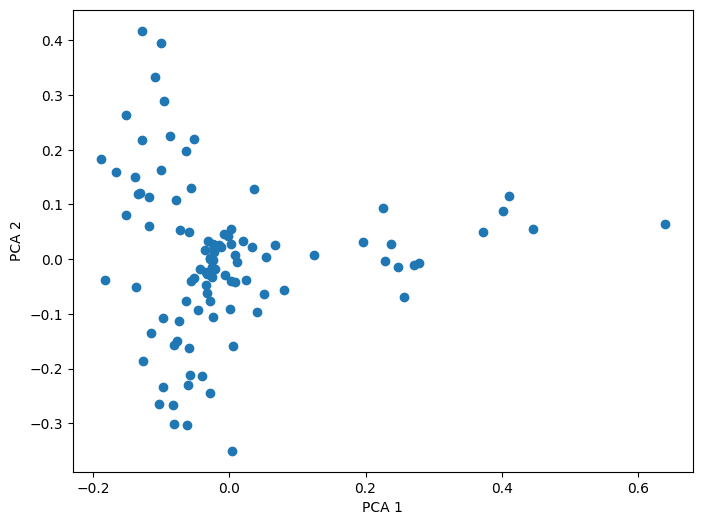

In [111]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X = pca.fit_transform(X)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    X[:,0],
    X[:,1]
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.show()

### Contagem de tags dos clusters

In [ ]:
for cluster in sorted(df["cluster"].unique()):

    print("\n")
    print("="*60)
    print(f"CLUSTER {cluster}")

    # pegar tags do cluster
    tags_cluster = df[
        df["cluster"] == cluster
    ]["tags"]

    # juntar todas as tags
    todas_tags = []

    for lista_tags in tags_cluster:

        todas_tags.extend(lista_tags)
    todas_tags = [
    tag for tag in todas_tags
    if tag != "attributed-no-source"
]

    # contar frequências
    frequencia = Counter(todas_tags)

    # mostrar top tags
    print(frequencia.most_common(10))

# Regressão Logistica para prever tag LOVE e LIFE a partir das frases

## Tag LOVE

In [126]:
df = pd.read_csv("Frases_completo.csv")
df_tfidf = pd.read_csv("TF_IDF.csv")

df_tfidf = df_tfidf[
    ~df_tfidf["tags"].apply(
        lambda tags: "attributed-no-source" in tags
    )
].copy()

df_tfidf["tag_love"] = df_tfidf["tags"].apply(
    lambda tags: 1 if "love" in tags else 0
)

print(df_tfidf["tag_love"].value_counts())
df_tfidf.shape

Task was destroyed but it is pending!
task: <Task pending name='Task-423' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\isabe\.venv\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-424' coro=<Kernel.shell_main() running at C:\Users\isabe\.venv\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\isabe\.venv\Lib\site-packages\zmq\eventloop\zmqstream.py:563]>
C:\Users\isabe\.venv\Lib\site-packages\pandas\core\internals\blocks.py:650: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  return type(self)(values, placement=self._mgr_locs, ndim=self.ndim, refs=refs)
Task was destroyed but it is pending!
task: <Task pending name='Task-424' coro=<Kernel.shell_main() running at C:\Users\isabe\.venv\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]>


tag_love
0    82
1    15
Name: count, dtype: int64


(97, 560)

In [ ]:
colunas_tfidf = [
    col for col in df_tfidf.columns
    if col.startswith("tfidf_")
]

X = df_tfidf[colunas_tfidf]

y = df_tfidf["tag_love"]

#### Modelo com penalização L1

In [ ]:
modelo = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    max_iter=1000,
    class_weight="balanced"
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

#### Modelo sem penalização L1

In [ ]:
modelo = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [ ]:
y_prob = cross_val_predict(
    modelo,
    X,
    y,
    cv=cv,
    method="predict_proba"
)

prob_love = y_prob[:,1]

# grid de thresholds
thresholds = np.arange(0.01, 1.00, 0.001)

melhor_f1 = 0
melhor_threshold = 0

for t in thresholds:

    y_pred = (prob_love >= t).astype(int)

    f1 = f1_score(y, y_pred)

    if f1 > melhor_f1:
        melhor_f1 = f1
        melhor_threshold = t

print("Melhor threshold:", melhor_threshold)
print("Melhor F1:", melhor_f1)

In [ ]:
y_prob = cross_val_predict(
    modelo,
    X,
    y,
    cv=cv,
    method="predict_proba"
)

prob_love = y_prob[:,1]

y_pred = (prob_love >= melhor_threshold).astype(int)

print(
    classification_report(
        y,
        y_pred
    )
)


cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predito")
plt.ylabel("Real")

plt.title("Matriz de Confusão")

plt.show()

In [ ]:
pd.set_option('display.max_colwidth', None)
resultado = pd.DataFrame({
    "frase": df_tfidf["frase"],
    "tags": df_tfidf["tags"],
    "real": y,
    "probabilidade_love": prob_love,
    "predicao": y_pred
})

resultado.sort_values(
    by="probabilidade_love",
    ascending=False
).head(60)

## Tag LIFE

In [ ]:
df = pd.read_csv("Frases_completo.csv")
df_tfidf = pd.read_csv("TF_IDF.csv")

df_tfidf = df_tfidf[
    ~df_tfidf["tags"].apply(
        lambda tags: "attributed-no-source" in tags
    )
].copy()

df_tfidf["tag_love"] = df_tfidf["tags"].apply(
    lambda tags: 1 if "life" in tags else 0
)

print(df_tfidf["tag_love"].value_counts())
df_tfidf.shape

In [ ]:
colunas_tfidf = [
    col for col in df_tfidf.columns
    if col.startswith("tfidf_")
]

X = df_tfidf[colunas_tfidf]

y = df_tfidf["tag_love"]

#### Modelo com penalização L1

In [ ]:
modelo = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    max_iter=1000,
    class_weight="balanced"
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

#### Modelo sem penalização L1

In [ ]:
modelo = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [ ]:
y_prob = cross_val_predict(
    modelo,
    X,
    y,
    cv=cv,
    method="predict_proba"
)

prob_love = y_prob[:,1]

# grid de thresholds
thresholds = np.arange(0.01, 1.00, 0.001)

melhor_f1 = 0
melhor_threshold = 0

for t in thresholds:

    y_pred = (prob_love >= t).astype(int)

    f1 = f1_score(y, y_pred)

    if f1 > melhor_f1:
        melhor_f1 = f1
        melhor_threshold = t

print("Melhor threshold:", melhor_threshold)
print("Melhor F1:", melhor_f1)

In [ ]:
y_prob = cross_val_predict(
    modelo,
    X,
    y,
    cv=cv,
    method="predict_proba"
)

prob_love = y_prob[:,1]

y_pred = (prob_love >= melhor_threshold).astype(int)

print(
    classification_report(
        y,
        y_pred
    )
)


cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predito")
plt.ylabel("Real")

plt.title("Matriz de Confusão")

plt.show()

In [ ]:
pd.set_option('display.max_colwidth', None)
resultado = pd.DataFrame({
    "frase": df_tfidf["frase"],
    "tags": df_tfidf["tags"],
    "real": y,
    "probabilidade_life": prob_love,
    "predicao": y_pred
})

resultado.sort_values(
    by="probabilidade_life",
    ascending=False
).head(60)